# Churn Prediction for Online Retail
Notebook khung cho project môn Data-Driven Marketing.

**Framing:** retail phi hợp đồng, nhãn churn được tạo bằng time window.

**Dataset:** `/mnt/data/Online_Retail (2).xlsx`

## 1. Import libraries

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

## 2. Load data

In [25]:
DATA_PATH = r"Online_Retail (2).xlsx"

df = pd.read_excel(DATA_PATH)
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Clean transactions
- Drop missing `CustomerID`
- Keep only positive `Quantity` and `UnitPrice`
- Remove cancelled invoices starting with `C`
- Create `Sales`

In [26]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Sales'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype('Int64')

clean = df[
    df['CustomerID'].notna() &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['InvoiceNo'].astype(str).str.startswith('C'))
].copy()

print('Raw shape:', df.shape)
print('Clean shape:', clean.shape)
print('Customers:', clean['CustomerID'].nunique())
print('Invoices:', clean['InvoiceNo'].nunique())
print('Date range:', clean['InvoiceDate'].min(), '->', clean['InvoiceDate'].max())

Raw shape: (541909, 9)
Clean shape: (397884, 9)
Customers: 4338
Invoices: 18532
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


## 4. Quick EDA

In [27]:
monthly = clean.assign(month=clean['InvoiceDate'].dt.to_period('M').astype(str)) \
    .groupby('month') \
    .agg(
        sales=('Sales', 'sum'),
        invoices=('InvoiceNo', 'nunique'),
        customers=('CustomerID', 'nunique')
    )

monthly

,sales,invoices,customers
month,,,
2010-12,572713.890,1400,885
2011-01,569445.040,987,741
2011-02,447137.350,997,758
2011-03,595500.760,1321,974
2011-04,469200.361,1149,856
2011-05,678594.560,1555,1056
2011-06,661213.690,1393,991
2011-07,600091.011,1331,949
2011-08,645343.900,1280,935


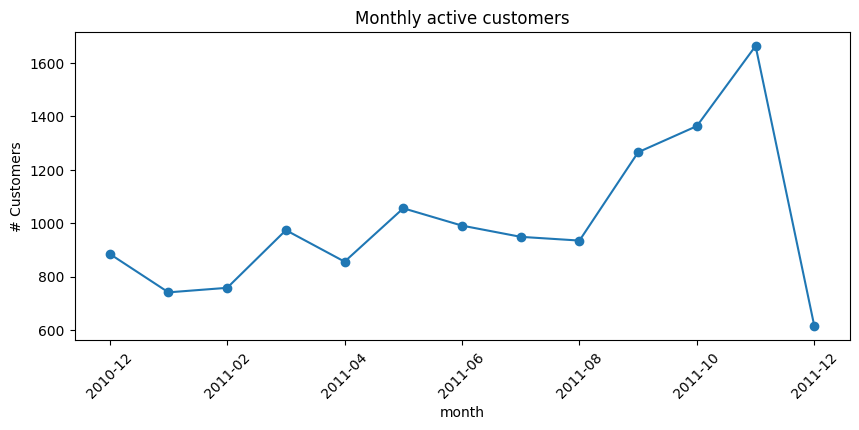

In [28]:
plt.figure(figsize=(10,4))
monthly['customers'].plot(marker='o')
plt.title('Monthly active customers')
plt.ylabel('# Customers')
plt.xticks(rotation=45)
plt.show()

## 5. Convert to invoice-level table
Mỗi invoice là một đơn vị hành vi gọn hơn transaction-line.

In [29]:
inv = clean.groupby(['CustomerID', 'InvoiceNo']).agg(
    InvoiceDate=('InvoiceDate', 'min'),
    Sales=('Sales', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index().sort_values(['CustomerID', 'InvoiceDate'])

inv['prev_date'] = inv.groupby('CustomerID')['InvoiceDate'].shift(1)
inv['gap_days'] = (inv['InvoiceDate'] - inv['prev_date']).dt.days

inv.head()

,CustomerID,InvoiceNo,InvoiceDate,Sales,Quantity,prev_date,gap_days
0,12346,541431,2011-01-18 10:01:00,77183.60,74215,NaT,NaN
1,12347,537626,2010-12-07 14:57:00,711.79,319,NaT,NaN
2,12347,542237,2011-01-26 14:30:00,475.39,315,2010-12-07 14:57:00,49.0
3,12347,549222,2011-04-07 10:43:00,636.25,483,2011-01-26 14:30:00,70.0
4,12347,556201,2011-06-09 13:01:00,382.52,196,2011-04-07 10:43:00,63.0


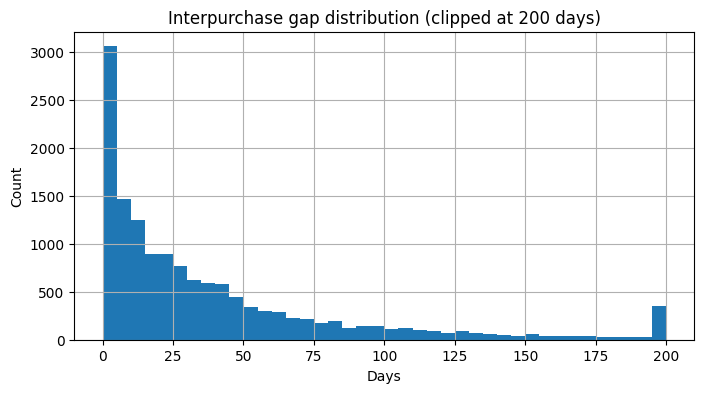

count    14194.000000
mean        39.519868
std         51.845967
min          0.000000
50%         21.000000
75%         51.000000
90%        102.700000
max        365.000000
Name: gap_days, dtype: float64


In [30]:
plt.figure(figsize=(8,4))
inv['gap_days'].dropna().clip(upper=200).hist(bins=40)
plt.title('Interpurchase gap distribution (clipped at 200 days)')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

print(inv['gap_days'].dropna().describe(percentiles=[0.5,0.75,0.9]))

## 6. Build monthly snapshots
### Churn definition
- Snapshot cuối tháng
- Feature window: 30/60/90 ngày quá khứ
- Label `churn_90d = 1` nếu **không mua** trong 90 ngày tới

In [31]:
snapshots = pd.to_datetime([
    '2011-03-31', '2011-04-30', '2011-05-31',
    '2011-06-30', '2011-07-31', '2011-08-31'
])

rows = []
for snap in snapshots:
    past = inv[inv['InvoiceDate'] <= snap]
    future = inv[(inv['InvoiceDate'] > snap) & (inv['InvoiceDate'] <= snap + pd.Timedelta(days=90))]
    future_active = set(future['CustomerID'].unique())

    past30 = past[past['InvoiceDate'] > snap - pd.Timedelta(days=30)]
    past60 = past[past['InvoiceDate'] > snap - pd.Timedelta(days=60)]
    past90 = past[past['InvoiceDate'] > snap - pd.Timedelta(days=90)]

    agg_all = past.groupby('CustomerID').agg(
        first_purchase=('InvoiceDate', 'min'),
        last_purchase=('InvoiceDate', 'max'),
        orders_lifetime=('InvoiceNo', 'nunique'),
        sales_lifetime=('Sales', 'sum'),
        avg_order_value=('Sales', 'mean')
    )

    agg30 = past30.groupby('CustomerID').agg(
        orders_30d=('InvoiceNo', 'nunique'),
        sales_30d=('Sales', 'sum')
    )
    agg60 = past60.groupby('CustomerID').agg(
        orders_60d=('InvoiceNo', 'nunique'),
        sales_60d=('Sales', 'sum')
    )
    agg90 = past90.groupby('CustomerID').agg(
        orders_90d=('InvoiceNo', 'nunique'),
        sales_90d=('Sales', 'sum')
    )

    feat = agg_all.join(agg30, how='left').join(agg60, how='left').join(agg90, how='left').fillna(0)
    feat['snapshot_date'] = snap
    feat['recency_days'] = (snap - feat['last_purchase']).dt.days
    feat['tenure_days'] = (snap - feat['first_purchase']).dt.days
    feat['velocity_30_90'] = feat['orders_30d'] / ((feat['orders_90d'].replace(0, np.nan)) / 3)
    feat['velocity_30_90'] = feat['velocity_30_90'].replace([np.inf, -np.inf], np.nan).fillna(0)
    feat['churn_90d'] = (~feat.index.isin(future_active)).astype(int)

    rows.append(feat.reset_index())

panel = pd.concat(rows, ignore_index=True)
print(panel.shape)
panel.head()

(16667, 17)


,CustomerID,first_purchase,last_purchase,orders_lifetime,sales_lifetime,avg_order_value,orders_30d,sales_30d,orders_60d,sales_60d,orders_90d,sales_90d,snapshot_date,recency_days,tenure_days,velocity_30_90,churn_90d
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600,0.0,0.00,0.0,0.00,1.0,77183.60,2011-03-31,71,71,0.0,1
1,12347,2010-12-07 14:57:00,2011-01-26 14:30:00,2,1187.18,593.590,0.0,0.00,0.0,0.00,1.0,475.39,2011-03-31,63,113,0.0,0
2,12348,2010-12-16 19:09:00,2011-01-25 10:42:00,2,1120.24,560.120,0.0,0.00,0.0,0.00,1.0,227.44,2011-03-31,64,104,0.0,0
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400,0.0,0.00,1.0,334.40,1.0,334.40,2011-03-31,56,56,0.0,1
4,12352,2011-02-16 12:33:00,2011-03-22 16:08:00,5,1561.81,312.362,4.0,1265.31,5.0,1561.81,5.0,1561.81,2011-03-31,8,42,2.4,1


## 7. Keep the actionable population
Gợi ý:
- `orders_lifetime >= 2`
- `recency_days <= 180`

Mục tiêu là loại bớt khách đã quá “nguội” hoặc mới chỉ ghé qua một lần.

In [32]:
panel = panel[(panel['orders_lifetime'] >= 2) & (panel['recency_days'] <= 180)].copy()

print(panel.shape)
print('Churn rate:', panel['churn_90d'].mean())
panel.groupby('snapshot_date')['churn_90d'].agg(['count', 'mean'])

(8526, 17)
Churn rate: 0.30272108843537415


,count,mean
snapshot_date,,
2011-03-31,878,0.249431
2011-04-30,1106,0.271248
2011-05-31,1377,0.323893
2011-06-30,1575,0.337143
2011-07-31,1740,0.317241
2011-08-31,1850,0.288108


## 8. Extra features

In [33]:
panel['avg_sales_per_order_90d'] = np.where(panel['orders_90d'] > 0, panel['sales_90d'] / panel['orders_90d'], 0)
panel['avg_sales_per_order_lifetime'] = np.where(panel['orders_lifetime'] > 0, panel['sales_lifetime'] / panel['orders_lifetime'], 0)
panel['order_share_30d'] = np.where(panel['orders_90d'] > 0, panel['orders_30d'] / panel['orders_90d'], 0)
panel['sales_share_30d'] = np.where(panel['sales_90d'] > 0, panel['sales_30d'] / panel['sales_90d'], 0)
panel['orders_prev60'] = panel['orders_90d'] - panel['orders_30d']
panel['sales_prev60'] = panel['sales_90d'] - panel['sales_30d']
panel['order_change_30_vs_prev60_avg'] = panel['orders_30d'] - (panel['orders_prev60'] / 2)
panel['sales_change_30_vs_prev60_avg'] = panel['sales_30d'] - (panel['sales_prev60'] / 2)

## 9. Time-based train / test split
Tuyệt đối không random split.

In [34]:
feature_cols = [
    'recency_days', 'tenure_days',
    'orders_30d', 'orders_60d', 'orders_90d',
    'sales_30d', 'sales_60d', 'sales_90d',
    'orders_lifetime', 'sales_lifetime',
    'avg_order_value', 'velocity_30_90',
    'avg_sales_per_order_90d', 'avg_sales_per_order_lifetime',
    'order_share_30d', 'sales_share_30d',
    'order_change_30_vs_prev60_avg', 'sales_change_30_vs_prev60_avg'
]

train = panel[panel['snapshot_date'] < pd.Timestamp('2011-08-31')].copy()
test = panel[panel['snapshot_date'] == pd.Timestamp('2011-08-31')].copy()

X_train = train[feature_cols]
y_train = train['churn_90d']
X_test = test[feature_cols]
y_test = test['churn_90d']

print(X_train.shape, X_test.shape)
print('Train churn rate:', y_train.mean())
print('Test churn rate:', y_test.mean())

(6676, 18) (1850, 18)
Train churn rate: 0.3067705212702217
Test churn rate: 0.2881081081081081


## 10. Train baseline models

In [35]:
logit = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

models = {
    'LogisticRegression': logit,
    'RandomForest': rf
}

In [36]:
results = []
model_objects = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    results.append({
        'model': name,
        'PR_AUC': average_precision_score(y_test, prob),
        'ROC_AUC': roc_auc_score(y_test, prob),
        'Precision@0.5': precision_score(y_test, pred),
        'Recall@0.5': recall_score(y_test, pred),
        'F1@0.5': f1_score(y_test, pred)
    })

    model_objects[name] = model
    test[f'prob_{name}'] = prob

results_df = pd.DataFrame(results).sort_values('PR_AUC', ascending=False)
results_df

,model,PR_AUC,ROC_AUC,Precision@0.5,Recall@0.5,F1@0.5
1,RandomForest,0.543610,0.753559,0.486448,0.639775,0.552674
0,LogisticRegression,0.483428,0.718812,0.418432,0.741088,0.534868


## 11. Precision-Recall curve

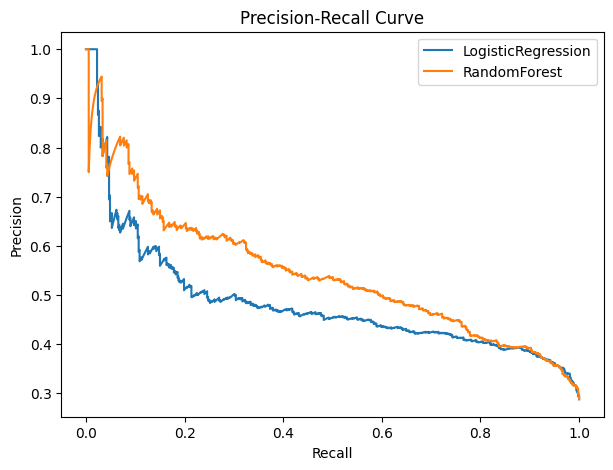

In [37]:
plt.figure(figsize=(7,5))

for name in models:
    precision, recall, _ = precision_recall_curve(y_test, test[f'prob_{name}'])
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 12. Lift / top-decile performance

In [38]:
def topk_metrics(y_true, scores, frac=0.1):
    n = len(y_true)
    k = max(1, int(np.ceil(n * frac)))
    idx = np.argsort(scores)[::-1][:k]
    y_sel = np.asarray(y_true)[idx]
    precision = y_sel.mean()
    baseline = np.mean(y_true)
    lift = precision / baseline if baseline > 0 else np.nan
    recall = y_sel.sum() / np.sum(y_true)
    return {
        'k': k,
        'precision': precision,
        'baseline': baseline,
        'lift': lift,
        'recall': recall
    }

for name in models:
    print(name, topk_metrics(y_test.values, test[f'prob_{name}'].values, frac=0.1))

LogisticRegression {'k': 185, 'precision': np.float64(0.5351351351351351), 'baseline': np.float64(0.2881081081081081), 'lift': np.float64(1.8574108818011257), 'recall': np.float64(0.18574108818011256)}
RandomForest {'k': 185, 'precision': np.float64(0.6324324324324324), 'baseline': np.float64(0.2881081081081081), 'lift': np.float64(2.195121951219512), 'recall': np.float64(0.21951219512195122)}


## 13. Threshold optimization by business profit
Đây là phần quan trọng để kể chuyện kinh doanh.

**Giả định có thể chỉnh:**
- `MARGIN = 0.20`
- `SAVE_RATE = 0.30`
- `CONTACT_COST = 10`

Công thức proxy:
`expected_profit = p_churn * SAVE_RATE * (sales_90d * MARGIN) - CONTACT_COST`

In [39]:
chosen_model = 'RandomForest'

MARGIN = 0.20
SAVE_RATE = 0.30
CONTACT_COST = 10.0

test['protected_margin_proxy'] = test['sales_90d'] * MARGIN
test['expected_profit_proxy'] = test[f'prob_{chosen_model}'] * SAVE_RATE * test['protected_margin_proxy'] - CONTACT_COST
test['target_flag_expected_profit'] = (test['expected_profit_proxy'] > 0).astype(int)

test[['CustomerID', f'prob_{chosen_model}', 'sales_90d', 'expected_profit_proxy', 'target_flag_expected_profit']].head()

,CustomerID,prob_RandomForest,sales_90d,expected_profit_proxy,target_flag_expected_profit
13356,12347,0.144946,967.43,-1.586469,0
13357,12348,0.273150,0.00,-10.000000,0
13359,12352,0.415465,0.00,-10.000000,0
13363,12356,0.822370,0.00,-10.000000,0
13365,12359,0.395889,1109.32,16.350065,1


In [40]:
thresholds = np.linspace(0.05, 0.95, 19)
rows = []

for th in thresholds:
    targeted = test[f'prob_{chosen_model}'] >= th
    # historical proxy: if actual churn==1 and targeted, we "recover" SAVE_RATE * protected margin
    profit = np.where(
        targeted,
        np.where(test['churn_90d'] == 1, SAVE_RATE * test['protected_margin_proxy'] - CONTACT_COST, -CONTACT_COST),
        0
    ).sum()

    rows.append({
        'threshold': th,
        'n_targeted': int(targeted.sum()),
        'profit_proxy': profit
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,n_targeted,profit_proxy
0,0.05,1718,-4876.7060
1,0.10,1613,-4538.6366
2,0.15,1481,-3939.3200
3,0.20,1384,-3737.5252
4,0.25,1281,-3179.5632
5,0.30,1162,-2942.2444
6,0.35,1046,-2902.5944
7,0.40,927,-2571.8784
8,0.45,803,-2079.0734
9,0.50,701,-1836.1682


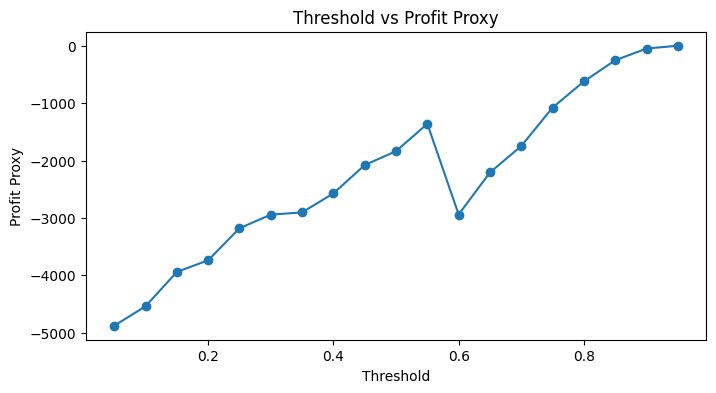

threshold       0.95
n_targeted      0.00
profit_proxy    0.00
Name: 18, dtype: float64

In [41]:
plt.figure(figsize=(8,4))
plt.plot(threshold_df['threshold'], threshold_df['profit_proxy'], marker='o')
plt.title('Threshold vs Profit Proxy')
plt.xlabel('Threshold')
plt.ylabel('Profit Proxy')
plt.show()

best_row = threshold_df.loc[threshold_df['profit_proxy'].idxmax()]
best_row

## 14. Export scored data for Power BI

In [42]:
export_cols = [
    'CustomerID', 'snapshot_date', 'churn_90d',
    'prob_LogisticRegression', 'prob_RandomForest',
    'recency_days', 'tenure_days',
    'orders_30d', 'orders_60d', 'orders_90d',
    'sales_30d', 'sales_60d', 'sales_90d',
    'orders_lifetime', 'sales_lifetime',
    'avg_order_value', 'velocity_30_90',
    'expected_profit_proxy', 'target_flag_expected_profit'
]

OUTPUT_PATH = 'powerbi_churn_scored_test.csv'
test[export_cols].to_csv(OUTPUT_PATH, index=False)
print('Saved to:', OUTPUT_PATH)

Saved to: powerbi_churn_scored_test.csv


In [44]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score

BASE = Path(".")
OUT = BASE / "powerbi_final_exports"
OUT.mkdir(parents=True, exist_ok=True)

score_candidates = [
    BASE / "powerbi_churn_scored_test.csv",
    Path("/mnt/data/powerbi_churn_scored_test.csv")
]

raw_candidates = [
    BASE / "Online_Retail (2).xlsx",
    BASE / "Online_Retail.xlsx",
    Path("/mnt/data/Online_Retail (2).xlsx"),
    Path("/mnt/data/Online_Retail.xlsx"),
]

score_path = None
for p in score_candidates:
    if p.exists():
        score_path = p
        break

if score_path is None:
    raise FileNotFoundError("Không tìm thấy powerbi_churn_scored_test.csv")

df = pd.read_csv(score_path)

def norm_col(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
        .replace(".", "")
        .replace("/", "")
    )

norm_map = {c: norm_col(c) for c in df.columns}

def try_numeric(s):
    if s.dtype.kind in "biufc":
        return pd.to_numeric(s, errors="coerce")
    s2 = (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(s2, errors="coerce")

def is_binary_series(s):
    x = try_numeric(s).dropna()
    if len(x) == 0:
        return False
    vals = set(pd.Series(x).round(10).unique().tolist())
    return vals.issubset({0, 1})

def find_exact(possible_names):
    possible_names = {norm_col(x) for x in possible_names}
    for c, n in norm_map.items():
        if n in possible_names:
            return c
    return None

def find_contains(required_terms, forbidden_terms=None, require_all=False, numeric_only=False, exclude_binary=False):
    forbidden_terms = forbidden_terms or []
    for c, n in norm_map.items():
        ok_required = all(t in n for t in required_terms) if require_all else any(t in n for t in required_terms)
        ok_forbidden = not any(t in n for t in forbidden_terms)
        if ok_required and ok_forbidden:
            if numeric_only:
                s = try_numeric(df[c])
                if s.notna().sum() == 0:
                    continue
            if exclude_binary and is_binary_series(df[c]):
                continue
            return c
    return None

def infer_customer_col():
    c = find_exact(["CustomerID", "customer_id", "CustomerId", "cust_id", "custid", "customer"])
    if c:
        return c
    return find_contains(["customer", "cust"], forbidden_terms=["country"])

def infer_date_col():
    c = find_exact(["snapshot_date", "SnapshotDate", "as_of_date", "date", "score_date"])
    if c:
        return c
    candidates = []
    for col, n in norm_map.items():
        if any(k in n for k in ["snapshot", "asof", "date", "time"]):
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().sum() > 0:
                candidates.append((col, parsed.notna().sum()))
    if candidates:
        candidates.sort(key=lambda x: x[1], reverse=True)
        return candidates[0][0]
    return None

def infer_label_col():
    exact = find_exact([
        "churn_90d", "actual_churn", "ActualChurn", "label", "target", "y_true", "y"
    ])
    if exact:
        return exact

    preferred = []
    for c, n in norm_map.items():
        if any(k in n for k in ["actual", "label", "target", "ytrue", "outcome"]):
            if not any(k in n for k in ["pred", "prob", "score"]):
                preferred.append(c)

    for c in preferred:
        if is_binary_series(df[c]):
            return c

    for c, n in norm_map.items():
        if "churn" in n and not any(k in n for k in ["pred", "prob", "score"]):
            if is_binary_series(df[c]):
                return c

    for c in df.columns:
        if is_binary_series(df[c]):
            return c

    return None

def infer_value_col():
    exact = find_exact([
        "cur_sales", "sales_90d", "value_proxy", "revenue_90d", "sales",
        "revenue", "monetary", "amount", "spend"
    ])
    if exact:
        return exact

    c = find_contains(
        ["sales", "revenue", "value", "monetary", "amount", "spend"],
        forbidden_terms=["prob", "score", "rank", "churn", "pred"],
        numeric_only=True
    )
    return c

def infer_prob_col(label_col=None):
    exact = find_exact([
        "score", "p_churn", "churn_probability", "probability",
        "ChurnProbability", "pred_proba", "predprob", "rf_score",
        "risk_score", "riskscore", "predicted_probability",
        "predictedprobability", "churnprob", "prob"
    ])
    if exact and not is_binary_series(df[exact]):
        return exact

    numeric_candidates = []
    for c in df.columns:
        s = try_numeric(df[c])
        non_na = s.notna().sum()
        nunique = s.nunique(dropna=True)
        if non_na == 0 or nunique <= 2:
            continue
        s_valid = s.dropna()
        in_01 = ((s_valid >= 0) & (s_valid <= 1)).mean()
        in_0100 = ((s_valid >= 0) & (s_valid <= 100)).mean()
        numeric_candidates.append({
            "col": c,
            "non_na": non_na,
            "nunique": nunique,
            "in_01": in_01,
            "in_0100": in_0100,
            "norm": norm_map[c]
        })

    named_good = []
    for item in numeric_candidates:
        n = item["norm"]
        if any(k in n for k in ["prob", "score", "risk", "pred", "churn"]):
            if not any(k in n for k in ["rank", "decile"]):
                named_good.append(item)

    named_good_01 = [x for x in named_good if x["in_01"] >= 0.95]
    if named_good_01:
        if label_col and label_col in df.columns and is_binary_series(df[label_col]):
            y = try_numeric(df[label_col])
            scored = []
            for item in named_good_01:
                x = try_numeric(df[item["col"]])
                tmp = pd.concat([x, y], axis=1).dropna()
                if len(tmp) > 10:
                    corr = tmp.iloc[:, 0].corr(tmp.iloc[:, 1])
                    scored.append((item["col"], -999 if pd.isna(corr) else abs(corr)))
            if scored:
                scored.sort(key=lambda x: x[1], reverse=True)
                return scored[0][0]
        return sorted(named_good_01, key=lambda x: (x["non_na"], x["nunique"]), reverse=True)[0]["col"]

    if named_good:
        named_good_0100 = [x for x in named_good if x["in_0100"] >= 0.95]
        if named_good_0100:
            return sorted(named_good_0100, key=lambda x: (x["non_na"], x["nunique"]), reverse=True)[0]["col"]

    generic_01 = [x for x in numeric_candidates if x["in_01"] >= 0.95]
    if generic_01:
        return sorted(generic_01, key=lambda x: (x["non_na"], x["nunique"]), reverse=True)[0]["col"]

    return None

customer_col = infer_customer_col()
label_col = infer_label_col()
prob_col = infer_prob_col(label_col=label_col)
value_col = infer_value_col()
date_col = infer_date_col()

if customer_col is None:
    raise ValueError(f"Không tự nhận diện được cột CustomerID. Các cột hiện có: {list(df.columns)}")

if prob_col is None:
    raise ValueError(
        "Không tự nhận diện được cột xác suất churn. "
        f"Các cột hiện có: {list(df.columns)}"
    )

work = df.copy()

rename_map = {
    customer_col: "CustomerID",
    prob_col: "ChurnProbability"
}
if label_col:
    rename_map[label_col] = "ActualChurn"
if value_col:
    rename_map[value_col] = "ValueProxy"
if date_col:
    rename_map[date_col] = "SnapshotDate"

work = work.rename(columns=rename_map)

work["CustomerID"] = work["CustomerID"].astype(str)

work["ChurnProbability"] = try_numeric(work["ChurnProbability"])

if work["ChurnProbability"].dropna().max() is not None:
    mx = work["ChurnProbability"].dropna().max()
    mn = work["ChurnProbability"].dropna().min()
    if mx > 1 and mx <= 100 and mn >= 0:
        work["ChurnProbability"] = work["ChurnProbability"] / 100.0

if "ActualChurn" in work.columns:
    y = work["ActualChurn"]
    if y.dtype.kind not in "biufc":
        y2 = (
            y.astype(str)
            .str.strip()
            .str.lower()
            .map({
                "1": 1, "0": 0,
                "true": 1, "false": 0,
                "yes": 1, "no": 0,
                "y": 1, "n": 0,
                "churn": 1, "non-churn": 0,
                "nonchurn": 0
            })
        )
        work["ActualChurn"] = y2
    work["ActualChurn"] = try_numeric(work["ActualChurn"])

if "ValueProxy" not in work.columns:
    work["ValueProxy"] = 0.0
else:
    work["ValueProxy"] = try_numeric(work["ValueProxy"]).fillna(0.0)

if "SnapshotDate" in work.columns:
    work["SnapshotDate"] = pd.to_datetime(work["SnapshotDate"], errors="coerce")

work = work.dropna(subset=["ChurnProbability"]).copy()

margin = 0.20
save_rate = 0.20
contact_cost = 5.0
budget = 1000.0
top_n_budget = int(budget // contact_cost)

work["ExpectedProfit"] = work["ChurnProbability"] * save_rate * margin * work["ValueProxy"] - contact_cost
work["PredictedChurn_050"] = (work["ChurnProbability"] >= 0.50).astype(int)
work["TargetFlag"] = (work["ExpectedProfit"] > 0).astype(int)

prob_rank = work["ChurnProbability"].rank(method="first", ascending=False)
profit_rank = work["ExpectedProfit"].rank(method="first", ascending=False)

work["RiskRank"] = prob_rank.astype(int)
work["ProfitRank"] = profit_rank.astype(int)
work["DecileNum"] = pd.qcut(prob_rank, 10, labels=list(range(1, 11))).astype(int)
work["DecileLabel"] = work["DecileNum"].apply(lambda x: f"D{x}")

risk_q1 = work["ChurnProbability"].quantile(1/3)
risk_q2 = work["ChurnProbability"].quantile(2/3)
value_q1 = work["ValueProxy"].quantile(1/3)
value_q2 = work["ValueProxy"].quantile(2/3)

def risk_tier(x):
    if x >= risk_q2:
        return "High Risk"
    if x >= risk_q1:
        return "Medium Risk"
    return "Low Risk"

def value_tier(x):
    if x >= value_q2:
        return "High Value"
    if x >= value_q1:
        return "Medium Value"
    return "Low Value"

work["RiskTier"] = work["ChurnProbability"].apply(risk_tier)
work["ValueTier"] = work["ValueProxy"].apply(value_tier)

def action_segment(row):
    if row["RiskTier"] == "High Risk" and row["ValueTier"] == "High Value":
        return "Save Now"
    if row["RiskTier"] == "High Risk" and row["ValueTier"] != "High Value":
        return "Low-cost Retention"
    if row["RiskTier"] != "High Risk" and row["ValueTier"] == "High Value":
        return "Protect / Monitor"
    return "Nurture"

work["ActionSegment"] = work.apply(action_segment, axis=1)

work = work.sort_values(["ProfitRank", "RiskRank", "CustomerID"], ascending=[True, True, True]).reset_index(drop=True)
work["CampaignRank"] = np.arange(1, len(work) + 1)
work["RecommendedByBudget"] = ((work["ExpectedProfit"] > 0) & (work["CampaignRank"] <= top_n_budget)).astype(int)

fact_cols = [
    c for c in [
        "CustomerID", "SnapshotDate", "ChurnProbability", "ActualChurn", "ValueProxy",
        "ExpectedProfit", "PredictedChurn_050", "TargetFlag", "RiskRank", "ProfitRank",
        "DecileNum", "DecileLabel", "RiskTier", "ValueTier", "ActionSegment",
        "CampaignRank", "RecommendedByBudget"
    ] if c in work.columns
]

fact_scored = work[fact_cols].copy()
fact_scored.to_csv(OUT / "fact_scored_customers.csv", index=False)

decile = work.groupby(["DecileNum", "DecileLabel"], as_index=False).agg(
    Customers=("CustomerID", "count"),
    AvgChurnProbability=("ChurnProbability", "mean"),
    AvgValueProxy=("ValueProxy", "mean"),
    AvgExpectedProfit=("ExpectedProfit", "mean")
)

if "ActualChurn" in work.columns and work["ActualChurn"].notna().sum() > 0:
    decile_actual = work.groupby(["DecileNum", "DecileLabel"], as_index=False).agg(
        ActualChurnRate=("ActualChurn", "mean"),
        ActualChurners=("ActualChurn", "sum")
    )
    decile = decile.merge(decile_actual, on=["DecileNum", "DecileLabel"], how="left")

decile = decile.sort_values("DecileNum")
decile.to_csv(OUT / "agg_decile_summary.csv", index=False)

action = work.groupby(["RiskTier", "ValueTier", "ActionSegment"], as_index=False).agg(
    Customers=("CustomerID", "count"),
    AvgChurnProbability=("ChurnProbability", "mean"),
    AvgValueProxy=("ValueProxy", "mean"),
    TotalExpectedProfit=("ExpectedProfit", "sum")
)

if "ActualChurn" in work.columns and work["ActualChurn"].notna().sum() > 0:
    action_actual = work.groupby(["RiskTier", "ValueTier", "ActionSegment"], as_index=False).agg(
        ActualChurnRate=("ActualChurn", "mean")
    )
    action = action.merge(action_actual, on=["RiskTier", "ValueTier", "ActionSegment"], how="left")

action.to_csv(OUT / "agg_action_segments.csv", index=False)

target_list = work.loc[work["RecommendedByBudget"] == 1].copy()
target_list["CumulativeCost"] = np.arange(1, len(target_list) + 1) * contact_cost
target_list["CumulativeExpectedProfit"] = target_list["ExpectedProfit"].cumsum()

target_cols = [
    c for c in [
        "CustomerID", "ChurnProbability", "ValueProxy", "ExpectedProfit",
        "RiskTier", "ValueTier", "ActionSegment", "CampaignRank",
        "CumulativeCost", "CumulativeExpectedProfit"
    ] if c in target_list.columns
]
target_list[target_cols].to_csv(OUT / "fact_target_recommendations.csv", index=False)

metrics_rows = []
metrics_rows.append({"Metric": "Customers scored", "Value": float(len(work))})
metrics_rows.append({"Metric": "Avg churn probability", "Value": float(work["ChurnProbability"].mean())})
metrics_rows.append({"Metric": "Target customers by budget", "Value": float(work["RecommendedByBudget"].sum())})
metrics_rows.append({"Metric": "Total expected profit (targeted)", "Value": float(target_list["ExpectedProfit"].sum()) if len(target_list) else 0.0})
metrics_rows.append({"Metric": "Budget", "Value": float(budget)})
metrics_rows.append({"Metric": "Contact cost", "Value": float(contact_cost)})
metrics_rows.append({"Metric": "Margin", "Value": float(margin)})
metrics_rows.append({"Metric": "Save rate assumption", "Value": float(save_rate)})

if "ActualChurn" in work.columns and work["ActualChurn"].notna().sum() > 0:
    valid = work.dropna(subset=["ActualChurn", "ChurnProbability"]).copy()
    if len(valid) > 0:
        metrics_rows.append({"Metric": "Actual churn rate", "Value": float(valid["ActualChurn"].mean())})
        metrics_rows.append({"Metric": "PR-AUC", "Value": float(average_precision_score(valid["ActualChurn"], valid["ChurnProbability"]))})
        metrics_rows.append({"Metric": "ROC-AUC", "Value": float(roc_auc_score(valid["ActualChurn"], valid["ChurnProbability"]))})

        top10 = valid.sort_values("ChurnProbability", ascending=False).head(max(1, int(len(valid) * 0.10)))
        top20 = valid.sort_values("ChurnProbability", ascending=False).head(max(1, int(len(valid) * 0.20)))
        base = valid["ActualChurn"].mean()

        metrics_rows.append({"Metric": "Top 10% precision", "Value": float(top10["ActualChurn"].mean())})
        metrics_rows.append({"Metric": "Top 10% lift", "Value": float(top10["ActualChurn"].mean() / base) if base > 0 else np.nan})
        metrics_rows.append({"Metric": "Top 20% precision", "Value": float(top20["ActualChurn"].mean())})
        metrics_rows.append({"Metric": "Top 20% lift", "Value": float(top20["ActualChurn"].mean() / base) if base > 0 else np.nan})

pd.DataFrame(metrics_rows).to_csv(OUT / "kpi_model_metrics.csv", index=False)

raw_path = None
for p in raw_candidates:
    if p.exists():
        raw_path = p
        break

if raw_path is not None:
    raw = pd.read_excel(raw_path)
    raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
    raw = raw.dropna(subset=["InvoiceDate"]).copy()

    if "CustomerID" in raw.columns:
        raw = raw.dropna(subset=["CustomerID"]).copy()

    if "InvoiceNo" in raw.columns:
        raw = raw[~raw["InvoiceNo"].astype(str).str.startswith("C")].copy()

    if "Quantity" in raw.columns:
        raw = raw[raw["Quantity"] > 0].copy()

    if "UnitPrice" in raw.columns:
        raw = raw[raw["UnitPrice"] > 0].copy()

    raw["Sales"] = raw["Quantity"] * raw["UnitPrice"]

    max_date = raw["InvoiceDate"].max()
    month_end = max_date.to_period("M").end_time.normalize()
    if max_date.normalize() < month_end:
        last_period = max_date.to_period("M")
        raw = raw.loc[raw["InvoiceDate"].dt.to_period("M") != last_period].copy()

    raw["YearMonth"] = raw["InvoiceDate"].dt.to_period("M").astype(str)

    monthly = raw.groupby("YearMonth", as_index=False).agg(
        Revenue=("Sales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    monthly.to_csv(OUT / "agg_monthly_kpi.csv", index=False)

print("=== DETECTED COLUMNS ===")
print("Customer column :", customer_col)
print("Probability col :", prob_col)
print("Label column    :", label_col)
print("Value column    :", value_col)
print("Date column     :", date_col)
print()
print("Đã xuất xong bộ bảng cho Power BI tại:", OUT.resolve())
print("Các file tạo ra:")
for f in sorted(OUT.iterdir()):
    print("-", f.name)

=== DETECTED COLUMNS ===
Customer column : CustomerID
Probability col : prob_RandomForest
Label column    : churn_90d
Value column    : sales_90d
Date column     : snapshot_date

Đã xuất xong bộ bảng cho Power BI tại: /Users/TranAnh/Documents/Data_file_NCKH/powerbi_final_exports
Các file tạo ra:
- agg_action_segments.csv
- agg_decile_summary.csv
- agg_monthly_kpi.csv
- fact_scored_customers.csv
- fact_target_recommendations.csv
- kpi_model_metrics.csv


## 15. Suggested next extensions
1. Add XGBoost / LightGBM
2. Add SHAP for explainability
3. Add CLV regression to replace simple `sales_90d` proxy
4. Add A/B test design to validate incremental retention